In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9279 - loss: 0.2551 - val_accuracy: 0.9617 - val_loss: 0.1341
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9675 - loss: 0.1115 - val_accuracy: 0.9707 - val_loss: 0.1005
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9774 - loss: 0.0745 - val_accuracy: 0.9744 - val_loss: 0.0861
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9823 - loss: 0.0570 - val_accuracy: 0.9744 - val_loss: 0.0850
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9862 - loss: 0.0444 - val_accuracy: 0.9764 - val_loss: 0.0780


In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9764 - loss: 0.0780
Test Loss : 0.07795130461454391
Test Accuracy : 0.9764000177383423


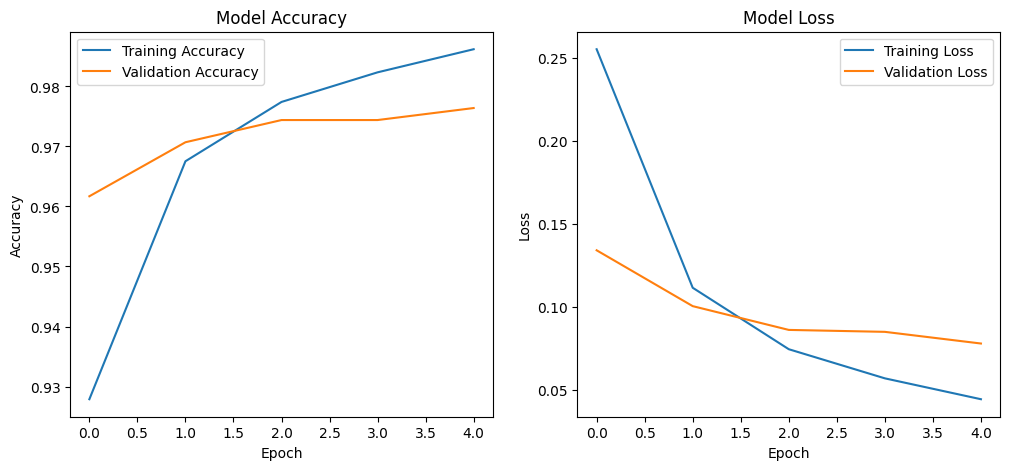

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.1)

In [ ]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

for lr in learning_rates:
    print(f"\nTraining with Learning Rate = {lr}")

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=5, verbose=0)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    print("Accuracy:", acc)



Training with Learning Rate = 0.1
Accuracy: 0.5432999730110168

Training with Learning Rate = 0.01
Accuracy: 0.9632999897003174

Training with Learning Rate = 0.001
Accuracy: 0.9778000116348267

Training with Learning Rate = 0.0001
Accuracy: 0.9502000212669373


In [ ]:
epochs_list = [1, 5, 10, 20]

for ep in epochs_list:
    print(f"\nTraining with Epochs = {ep}")

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=ep, verbose=0)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    print("Accuracy:", acc)


Training with Epochs = 1
Accuracy: 0.95660001039505

Training with Epochs = 5
Accuracy: 0.9764000177383423

Training with Epochs = 10
Accuracy: 0.977400004863739

Training with Epochs = 20
Accuracy: 0.9796000123023987
